In [815]:
import csv
import networkx as nx
from networkx import Graph
import matplotlib.pyplot as plt
import mplcursors

In [816]:
DATA_FOLDER = "../data/"
CSV_EDGES_COOCCURRENCES_NETWORK = f"{DATA_FOLDER}edges_cooccurrence_network.csv"
LIST_OF_YEARS = ["1996", "1997", "1998", "1999", "2000", "2001", "2002", "2003", "2005", "2006", "2007", "2024"]
YEAR_FROM_1996_TO_1999 = ["1996", "1997", "1998", "1999"]
YEAR_FROM_2000_TO_2007 = ["2000", "2001", "2002", "2003", "2005", "2006", "2007"]
YEAR_FROM_2024_TO_2024 = ["2024"]

In [817]:
def build_graph_for_year(year: str) -> Graph:
    G = nx.Graph()
    with open(CSV_EDGES_COOCCURRENCES_NETWORK, mode='r', encoding="utf-8") as file:
        csvFile = csv.reader(file)
        next(csvFile, None)  # skip the headers
        for line in csvFile:
            if line[3] == year:
                G.add_edge(line[0], line[1], weight=int(line[2]))

    return G

In [818]:
graphs_by_year = {year: build_graph_for_year( year) for year in LIST_OF_YEARS}

# Which countries consistently dominate negotiations?

In [819]:
# Mesure seulement le nombre de connexions, ignorant les poids
def degree_centrality_for_year(graph: Graph):
    return nx.degree_centrality(graph)

In [820]:
# Mesure le nombre de connexions en prenant en compte les poids
def weighted_degree_for_year(graph: Graph) -> dict[str, int]:
    return dict(graph.degree(weight="weight"))


In [821]:
# Normalise les degrés pondérés pour les comparer entre les années
def normalize_weighted_degree_for_year(weighted_degrees: dict[str, int]) -> dict[str, int]:
    max_value = max(weighted_degrees.values())
    return {node: value / max_value for node, value in weighted_degrees.items()}

In [822]:
# Mesure l'importance d'un nœud en fonction de l'importance de ses voisins
def eigenvector_centrality_for_year(graph: Graph) -> dict[str, float]:
    return nx.eigenvector_centrality(graph, weight="weight")

In [823]:
# Affiche les nœuds avec les plus hauts degrés pondérés
def sorted_by_cooccurrences_for_year(graph: Graph, reverse: bool = False) -> dict[str, int]:
    cooccurrences = {}
    for actor_1, actor_2, weight in graph.edges(data=True):
        weight_value = weight.get("weight", 0)
        cooccurrences[(actor_1, actor_2)] = weight_value

    return dict(sorted(cooccurrences.items(), key=lambda x: x[1], reverse=reverse))

In [824]:
def plot_top_n_grid_by_year(
    data_by_year: dict[str, dict[str, float]],
    title: str,
    title_x: str = "country",
    title_y: str = "title_y",
    top_n: int = 3,
    to_display_n: int = 12
):
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    years = sorted(data_by_year.keys())[:to_display_n]

    for i, year in enumerate(years):
        ax = axes[i]
        country_dict = data_by_year[year]

        top = sorted(country_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]

        countries = [country for country, _ in top]
        values = [value for _, value in top]

        ax.bar(countries, values)
        ax.set_title(f"{title} - {year}")
        ax.set_xlabel(title_x)
        ax.set_ylabel(title_y)
        ax.tick_params(axis="x", rotation=45)

    for j in range(len(years), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [825]:
def plot_top_cooccurrences_grid_by_year(
    data_by_year: dict[str, dict[tuple[str, str], float]],
    title: str,
    title_x: str = "Co-occurrence",
    title_y: str = "Weight",
    top_n: int = 3,
    to_display_n: int = 12
):
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    years = sorted(data_by_year.keys())[:min(to_display_n, len(axes))]

    for i, year in enumerate(years):
        ax = axes[i]
        cooccurrences_dict = data_by_year[year]

        top_items = list(cooccurrences_dict.items())[:top_n]

        labels = [f"{actor_1} - {actor_2}" for (actor_1, actor_2), _ in top_items]
        values = [value for _, value in top_items]

        ax.bar(labels, values)
        ax.set_title(f"{title} - {year}")
        ax.set_xlabel(title_x)
        ax.set_ylabel(title_y)
        ax.tick_params(axis="x", rotation=45)

    for j in range(len(years), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [826]:
normalize_weighted_degree_dict: dict[str, dict[str, int]] = {}
eigenvector_centrality_dict: dict[str, dict[str, float]] = {}
top_cooccurrences_dict: dict[str, dict[str, float]] = {}

for year in YEAR_FROM_2024_TO_2024[:12]:
    G = graphs_by_year[year]
    weighted_degree = weighted_degree_for_year(G)
    normalize_weighted_degree_dict[year] = normalize_weighted_degree_for_year(weighted_degree)
    eigenvector_centrality_dict[year] = eigenvector_centrality_for_year(G)
    top_cooccurrences_dict[year] = sorted_by_cooccurrences_for_year(G, True)

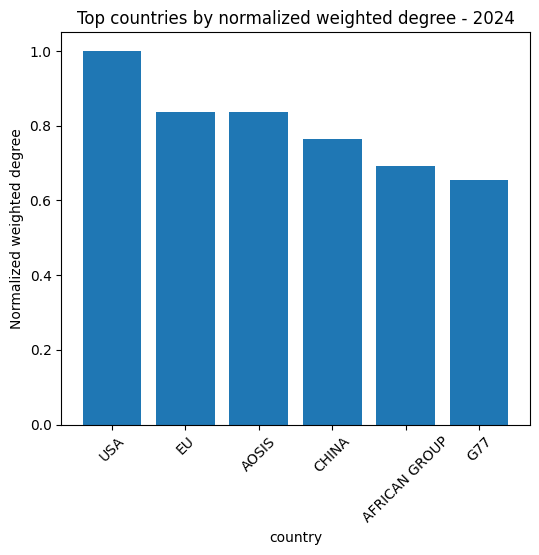

In [827]:
plot_top_n_grid_by_year(data_by_year=normalize_weighted_degree_dict, 
                        title="Top countries by normalized weighted degree", 
                        title_y="Normalized weighted degree",
                        top_n=6,
                        to_display_n=10)

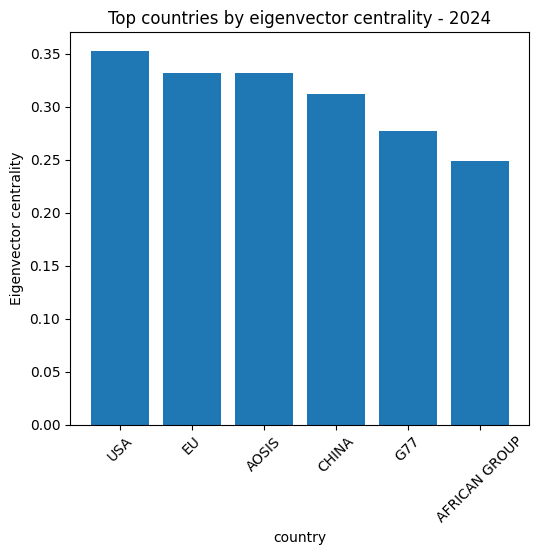

In [828]:
plot_top_n_grid_by_year(data_by_year=eigenvector_centrality_dict,
                        title="Top countries by eigenvector centrality",
                        title_y="Eigenvector centrality",
                        top_n=6,
                        to_display_n=10)

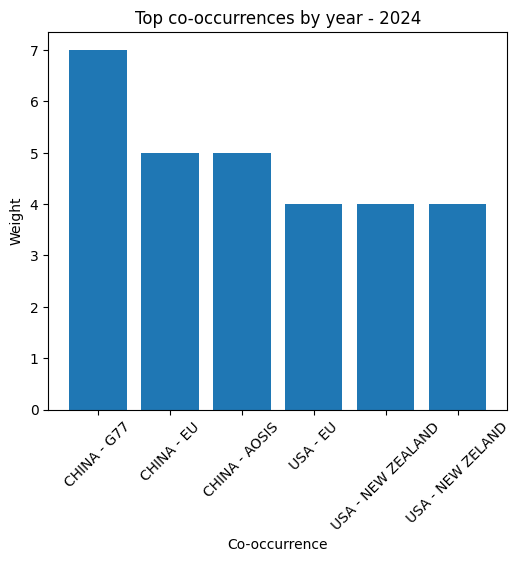

In [829]:
plot_top_cooccurrences_grid_by_year(data_by_year=top_cooccurrences_dict,
                                    title="Top co-occurrences by year",
                                    title_x="Co-occurrence",
                                    title_y="Weight",
                                    top_n=6,
                                    to_display_n=10)

- Which emerging actors (e.g., AOSIS, LDCs, India, Brazil) have increased influence?
- Are Global South alliances becoming more cohesive?
- Which countries act as bridges between blocs?
- How do finance, adaptation, and loss & damage negotiations differ in terms of interaction networks?